In [2]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os


os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("/content/kaggle.json", "/root/.kaggle/kaggle.json")


os.chmod("/root/.kaggle/kaggle.json", 0o600)

In [4]:
!pip install kaggle -q

In [5]:
!kaggle datasets download -d aryarishabh/hand-gesture-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/aryarishabh/hand-gesture-recognition-dataset
License(s): CC0-1.0
  0% 0.00/37.6M [00:00<?, ?B/s]
100% 37.6M/37.6M [00:00<00:00, 1.09GB/s]


In [6]:
import zipfile
with zipfile.ZipFile('/content/hand-gesture-recognition-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Done!")

Done!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU available:     ", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available:      True


In [8]:
import os

for item in os.listdir('/content/dataset/train'):
    print(item)

train


In [9]:
import os

for item in os.listdir('/content'):
    print(item)

.config
hand-gesture-recognition-dataset.zip
dataset
sample_data


In [10]:
import os

for item in os.listdir('/content/dataset'):
    print(item)

train
test


In [11]:
import os

TRAIN_DIR = '/content/dataset/train/train'
TEST_DIR  = '/content/dataset/test/test'

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:

IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
NUM_CLASSES = 20

class_names = sorted(os.listdir(TRAIN_DIR))
print("Classes:", class_names)
print("Total: ", len(class_names))

Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
Total:  20


In [14]:

base_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen_base = base_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
val_gen_base = base_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

Found 14400 images belonging to 20 classes.
Found 3600 images belonging to 20 classes.


In [15]:

aug_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen_aug = aug_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
val_gen_aug = aug_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

Found 14400 images belonging to 20 classes.
Found 3600 images belonging to 20 classes.


In [16]:

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print("\nAll data loaders ready!")
print(f"  Train batches: {len(train_gen_aug)}")
print(f"  Val batches:   {len(val_gen_aug)}")
print(f"  Test batches:  {len(test_gen)}")

Found 6000 images belonging to 20 classes.

All data loaders ready!
  Train batches: 450
  Val batches:   113
  Test batches:  188


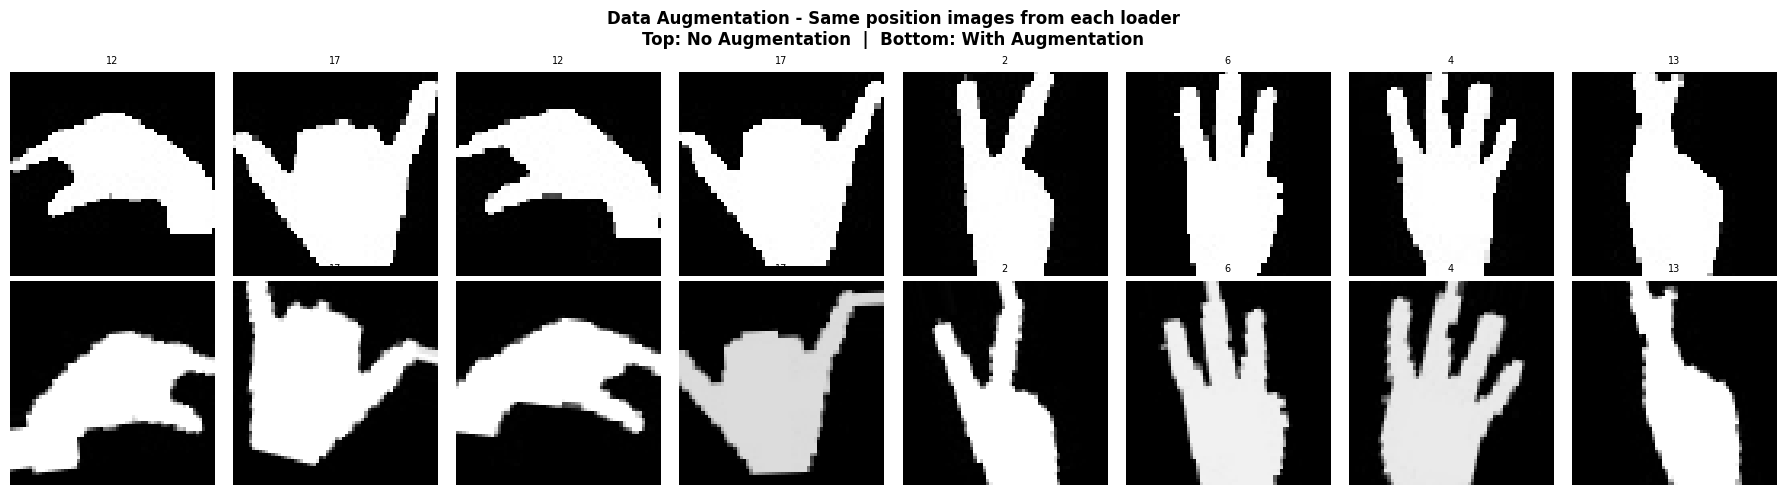

Saved: augmentation_comparison.png


In [17]:

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Data Augmentation - Same position images from each loader\nTop: No Augmentation  |  Bottom: With Augmentation',
             fontsize=12, fontweight='bold')

orig_imgs, orig_lbls = next(train_gen_base)
aug_imgs,  aug_lbls  = next(train_gen_aug)

for i in range(8):
    axes[0, i].imshow(orig_imgs[i])
    axes[0, i].set_title(class_names[np.argmax(orig_lbls[i])], fontsize=7)
    axes[0, i].axis('off')
    axes[1, i].imshow(aug_imgs[i])
    axes[1, i].set_title(class_names[np.argmax(aug_lbls[i])], fontsize=7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Augmented', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: augmentation_comparison.png")

In [18]:

model_v2 = keras.Sequential([


    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(64, 64, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),


    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),


    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),


    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_v2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,392,372 (9.13 MB)

 Trainable params: 2,390,964 (9.12 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [19]:
model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stop_v2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Model compailed")
history_v2 = model_v2.fit(
    train_gen_aug,
    epochs=30,
    validation_data=val_gen_aug,
    callbacks=[early_stop_v2, reduce_lr_v2],
    verbose=1
)

Model compailed
Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 77s 128ms/step - accuracy: 0.6399 - loss: 1.2059 - val_accuracy: 0.6933 - val_loss: 0.8218 - learning_rate: 0.0010
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.9394 - loss: 0.1943 - val_accuracy: 0.9608 - val_loss: 0.1222 - learning_rate: 0.0010
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.9576 - loss: 0.1311 - val_accuracy: 0.9833 - val_loss: 0.0511 - learning_rate: 0.0010
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.9784 - loss: 0.0742 - val_accuracy: 0.9731 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.9842 - loss: 0.0537 - val_accuracy: 0.9778 - val_loss: 0.0685 - learning_rate: 0.0010
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9806 - loss: 0.0627
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
450/450 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accur

In [20]:
epochs_v2   = len(history_v2.history['accuracy'])
best_val_v2 = max(history_v2.history['val_accuracy'])
print(f"\nmodel_v2 training complete!")
print(f"  Epochs trained:    {epochs_v2}")
print(f"  Best val accuracy: {best_val_v2*100:.2f}%")


model_v2 training complete!
  Epochs trained:    30
  Best val accuracy: 99.97%


In [21]:
test_gen.reset()
loss_v2, acc_v2 = model_v2.evaluate(test_gen, verbose=0)

test_gen.reset()
y_pred_v2 = np.argmax(model_v2.predict(test_gen, verbose=0), axis=1)
y_true     = test_gen.classes

print("=" * 45)
print("     model_v2 - Test Results")
print("=" * 45)
print(f"  Test Accuracy : {acc_v2 * 100:.2f}%")
print(f"  Test Loss     : {loss_v2:.4f}")
print("=" * 45)

print("\nClassification Report - model_v2:")
print(classification_report(y_true, y_pred_v2, target_names=class_names, digits=3))

     model_v2 - Test Results
  Test Accuracy : 100.00%
  Test Loss     : 0.0000

Classification Report - model_v2:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       300
           1      1.000     1.000     1.000       300
          10      1.000     1.000     1.000       300
          11      1.000     1.000     1.000       300
          12      1.000     1.000     1.000       300
          13      1.000     1.000     1.000       300
          14      1.000     1.000     1.000       300
          15      1.000     1.000     1.000       300
          16      1.000     1.000     1.000       300
          17      1.000     1.000     1.000       300
          18      1.000     1.000     1.000       300
          19      1.000     1.000     1.000       300
           2      1.000     1.000     1.000       300
           3      1.000     1.000     1.000       300
           4      1.000     1.000     1.000       300
           5      1.

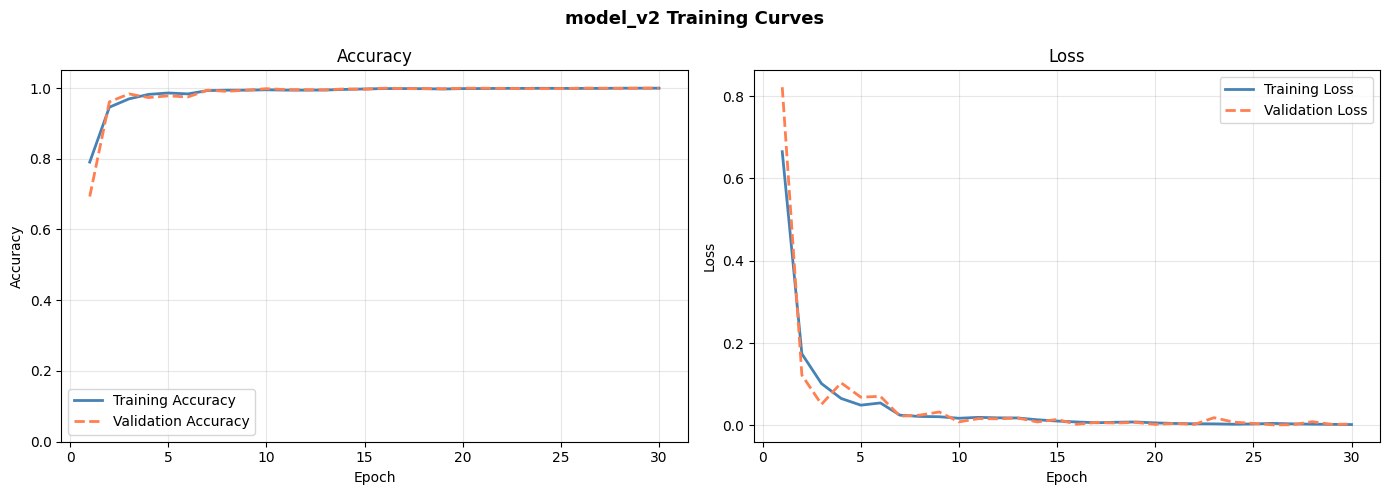

Saved: training_curves_v2.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('model_v2 Training Curves', fontsize=13, fontweight='bold')

ep = range(1, len(history_v2.history['accuracy']) + 1)

axes[0].plot(ep, history_v2.history['accuracy'],     label='Training Accuracy', linewidth=2, color='steelblue')
axes[0].plot(ep, history_v2.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='coral', linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 1.05])

axes[1].plot(ep, history_v2.history['loss'],     label='Training Loss', linewidth=2, color='steelblue')
axes[1].plot(ep, history_v2.history['val_loss'], label='Validation Loss', linewidth=2, color='coral', linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves_v2.png")

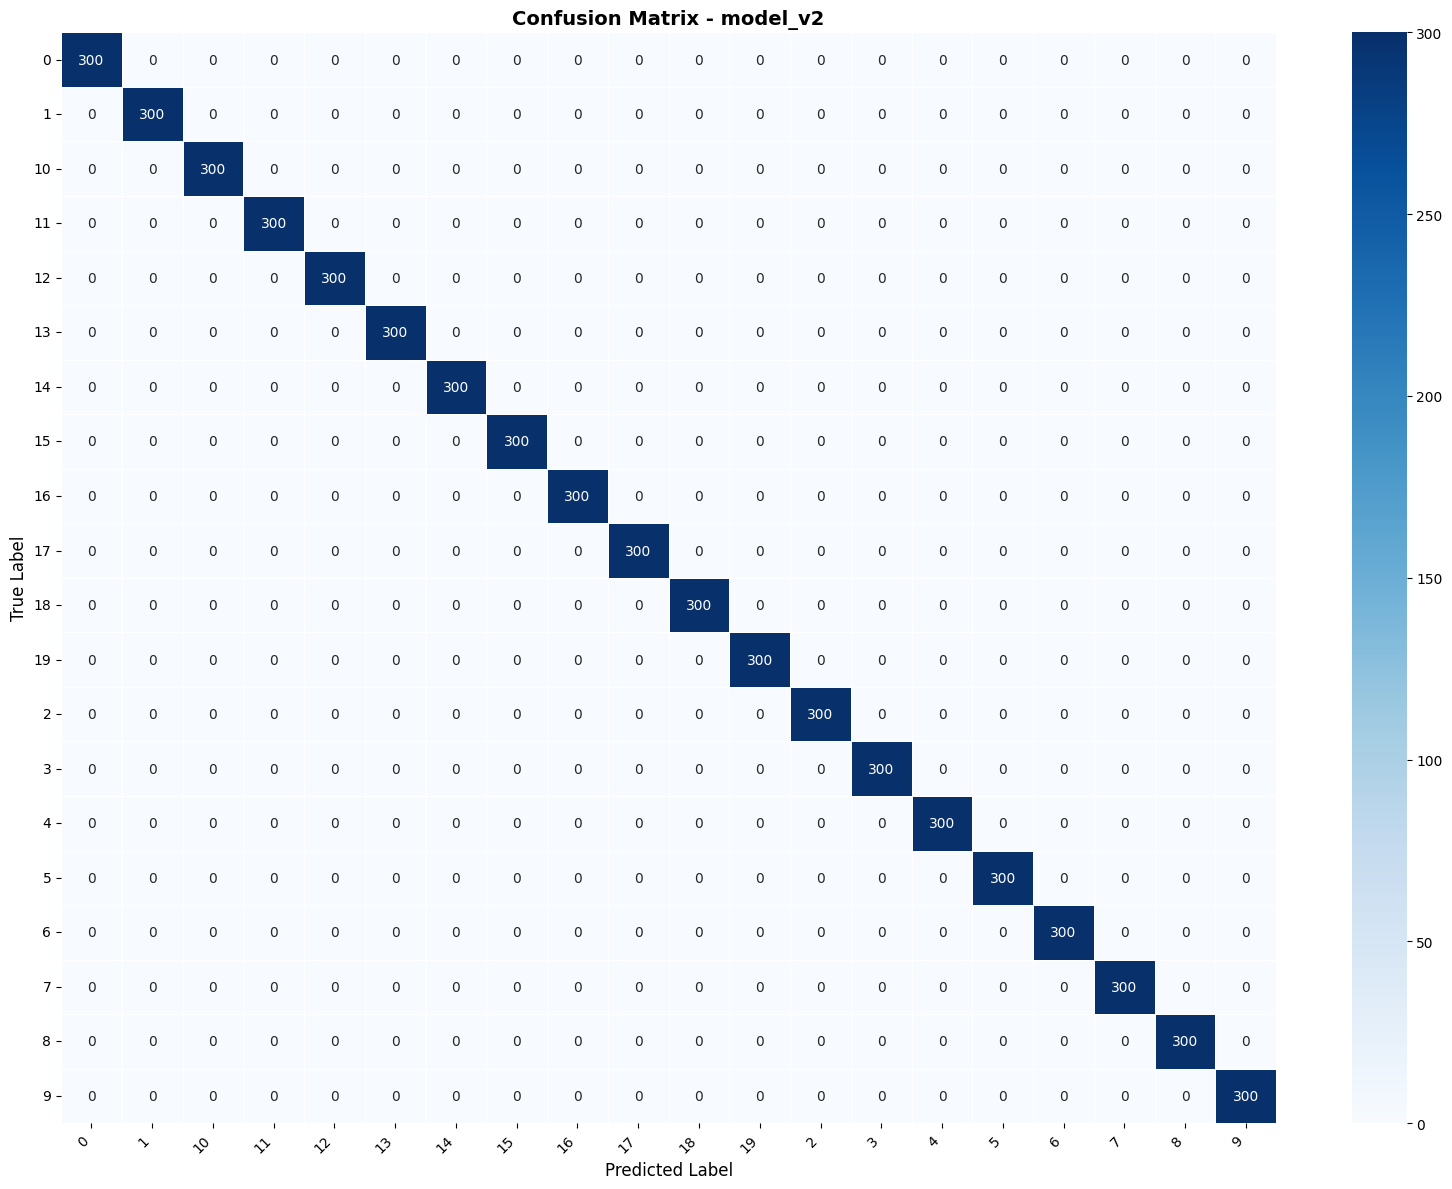

Saved: confusion_matrix_v2.png


In [23]:
cm_v2 = confusion_matrix(y_true, y_pred_v2)

plt.figure(figsize=(16, 12))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - model_v2', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_v2.png")

In [24]:

mobilenet_train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

mobilenet_test_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess
)

print("Datagenerators ready!")

Datagenerators ready!


In [25]:
MOBILENET_SIZE = (96, 96)

train_gen_mob = mobilenet_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=MOBILENET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
val_gen_mob = mobilenet_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=MOBILENET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
test_gen_mob = mobilenet_test_datagen.flow_from_directory(
    TEST_DIR, target_size=MOBILENET_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print("MobileNetV2 data loaders ready!")
print(f"  Image size used: {MOBILENET_SIZE}")

Found 14400 images belonging to 20 classes.
Found 3600 images belonging to 20 classes.
Found 6000 images belonging to 20 classes.
MobileNetV2 data loaders ready!
  Image size used: (96, 96)


In [26]:

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)


base_model.trainable = False

print("MobileNetV2 base loaded!")
print(f"  Total layers in base:     {len(base_model.layers)}")
print(f"  Trainable layers (frozen): {sum([l.trainable for l in base_model.layers])}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base loaded!
  Total layers in base:     154
  Trainable layers (frozen): 0


In [27]:

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)


model_v3 = Model(inputs=base_model.input, outputs=predictions)

print(f"\nmodel_v3 ready!")
print(f"  Total params (including frozen): {model_v3.count_params():,}")
trainable = sum([tf.size(w).numpy() for w in model_v3.trainable_weights])
print(f"  Trainable params only:           {trainable:,}")


model_v3 ready!
  Total params (including frozen): 2,591,060
  Trainable params only:           333,076


In [28]:

model_v3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_v3 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Training model_v3 - Stage 1: Feature Extraction")
print("(Only the new classifier layers are being trained)")

Training model_v3 - Stage 1: Feature Extraction
(Only the new classifier layers are being trained)


In [29]:
history_v3 = model_v3.fit(
    train_gen_mob,
    epochs=20,
    validation_data=val_gen_mob,
    callbacks=[early_stop_v3, reduce_lr_v3],
    verbose=1
)

epochs_v3   = len(history_v3.history['accuracy'])
best_val_v3 = max(history_v3.history['val_accuracy'])
print(f"\nStage 1 complete!")
print(f"  Epochs trained:    {epochs_v3}")
print(f"  Best val accuracy: {best_val_v3*100:.2f}%")

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.7550 - loss: 0.8362 - val_accuracy: 0.9864 - val_loss: 0.0610 - learning_rate: 0.0010
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.9640 - loss: 0.1193 - val_accuracy: 0.9844 - val_loss: 0.0461 - learning_rate: 0.0010
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.9736 - loss: 0.0802 - val_accuracy: 0.9900 - val_loss: 0.0328 - learning_rate: 0.0010
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 66s 147ms/step - accuracy: 0.9782 - loss: 0.0667 - val_accuracy: 0.9950 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 64s 143ms/step - accuracy: 0.9815 - loss: 0.0562 - val_accuracy: 0.9939 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 64s 142ms/step - accuracy: 0.9801 - loss: 0.0596 - val_accuracy: 0.9894 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9

In [30]:

base_model.trainable = True


for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_count = sum([l.trainable for l in base_model.layers])
print(f"Layers unfrozen for fine-tuning: {trainable_count}")


model_v3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining model_v3 - Stage 2: Fine-Tuning")
print("(Top 20 base layers now trainable with very low learning rate)")

Layers unfrozen for fine-tuning: 20

Training model_v3 - Stage 2: Fine-Tuning
(Top 20 base layers now trainable with very low learning rate)


In [31]:
history_v3_fine = model_v3.fit(
    train_gen_mob,
    epochs=10,
    validation_data=val_gen_mob,
    callbacks=[early_stop_v3, reduce_lr_v3],
    verbose=1
)

best_fine = max(history_v3_fine.history['val_accuracy'])
print(f"\nFine-tuning complete!")
print(f"  Best val accuracy after fine-tuning: {best_fine*100:.2f}%")

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 93s 163ms/step - accuracy: 0.7410 - loss: 1.6652 - val_accuracy: 0.9686 - val_loss: 0.0963 - learning_rate: 1.0000e-05
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 63s 140ms/step - accuracy: 0.9482 - loss: 0.2180 - val_accuracy: 0.9844 - val_loss: 0.0524 - learning_rate: 1.0000e-05
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 65s 145ms/step - accuracy: 0.9667 - loss: 0.1186 - val_accuracy: 0.9911 - val_loss: 0.0331 - learning_rate: 1.0000e-05
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 63s 140ms/step - accuracy: 0.9754 - loss: 0.0827 - val_accuracy: 0.9961 - val_loss: 0.0128 - learning_rate: 1.0000e-05
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 65s 146ms/step - accuracy: 0.9809 - loss: 0.0681 - val_accuracy: 0.9933 - val_loss: 0.0220 - learning_rate: 1.0000e-05
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 64s 141ms/step - accuracy: 0.9851 - loss: 0.0503 - val_accuracy: 0.9964 - val_loss: 0.0110 - learning_rate: 1.0000e-05
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 64s 14

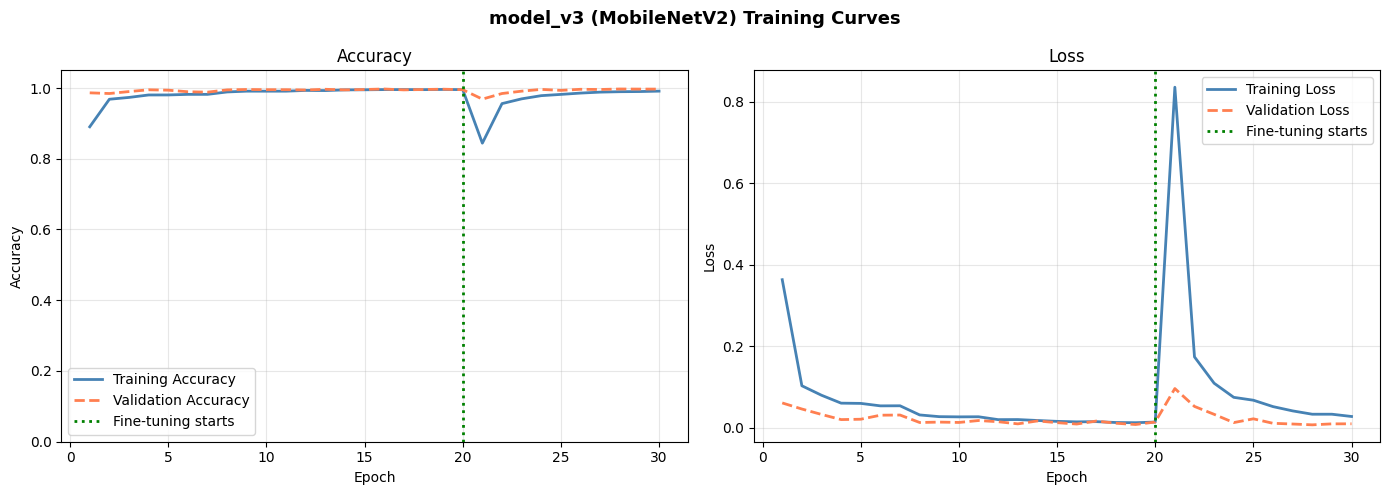

Saved: training_curves_v3.png


In [32]:

acc      = history_v3.history['accuracy']      + history_v3_fine.history['accuracy']
val_acc  = history_v3.history['val_accuracy']  + history_v3_fine.history['val_accuracy']
loss     = history_v3.history['loss']          + history_v3_fine.history['loss']
val_loss = history_v3.history['val_loss']      + history_v3_fine.history['val_loss']
fine_start = len(history_v3.history['accuracy'])

ep = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('model_v3 (MobileNetV2) Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(ep, acc,     label='Training Accuracy', linewidth=2, color='steelblue')
axes[0].plot(ep, val_acc, label='Validation Accuracy', linewidth=2, color='coral', linestyle='--')
axes[0].axvline(x=fine_start, color='green', linestyle=':', linewidth=2, label='Fine-tuning starts')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 1.05])

axes[1].plot(ep, loss,     label='Training Loss', linewidth=2, color='steelblue')
axes[1].plot(ep, val_loss, label='Validation Loss', linewidth=2, color='coral', linestyle='--')
axes[1].axvline(x=fine_start, color='green', linestyle=':', linewidth=2, label='Fine-tuning starts')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves_v3.png")

In [33]:
test_gen_mob.reset()
loss_v3, acc_v3 = model_v3.evaluate(test_gen_mob, verbose=0)

test_gen_mob.reset()
y_pred_v3 = np.argmax(model_v3.predict(test_gen_mob, verbose=0), axis=1)
y_true_mob = test_gen_mob.classes

print("=" * 45)
print("     model_v3 - Test Results")
print("=" * 45)
print(f"  Test Accuracy : {acc_v3 * 100:.2f}%")
print(f"  Test Loss     : {loss_v3:.4f}")
print("=" * 45)

print("\nClassification Report - model_v3:")
print(classification_report(y_true_mob, y_pred_v3, target_names=class_names, digits=3))

     model_v3 - Test Results
  Test Accuracy : 98.53%
  Test Loss     : 0.0471

Classification Report - model_v3:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       300
           1      1.000     1.000     1.000       300
          10      1.000     1.000     1.000       300
          11      0.987     1.000     0.993       300
          12      1.000     1.000     1.000       300
          13      0.997     1.000     0.998       300
          14      1.000     0.987     0.993       300
          15      1.000     1.000     1.000       300
          16      1.000     1.000     1.000       300
          17      1.000     1.000     1.000       300
          18      1.000     1.000     1.000       300
          19      1.000     1.000     1.000       300
           2      1.000     0.967     0.983       300
           3      0.952     1.000     0.976       300
           4      0.984     0.827     0.899       300
           5      0.8

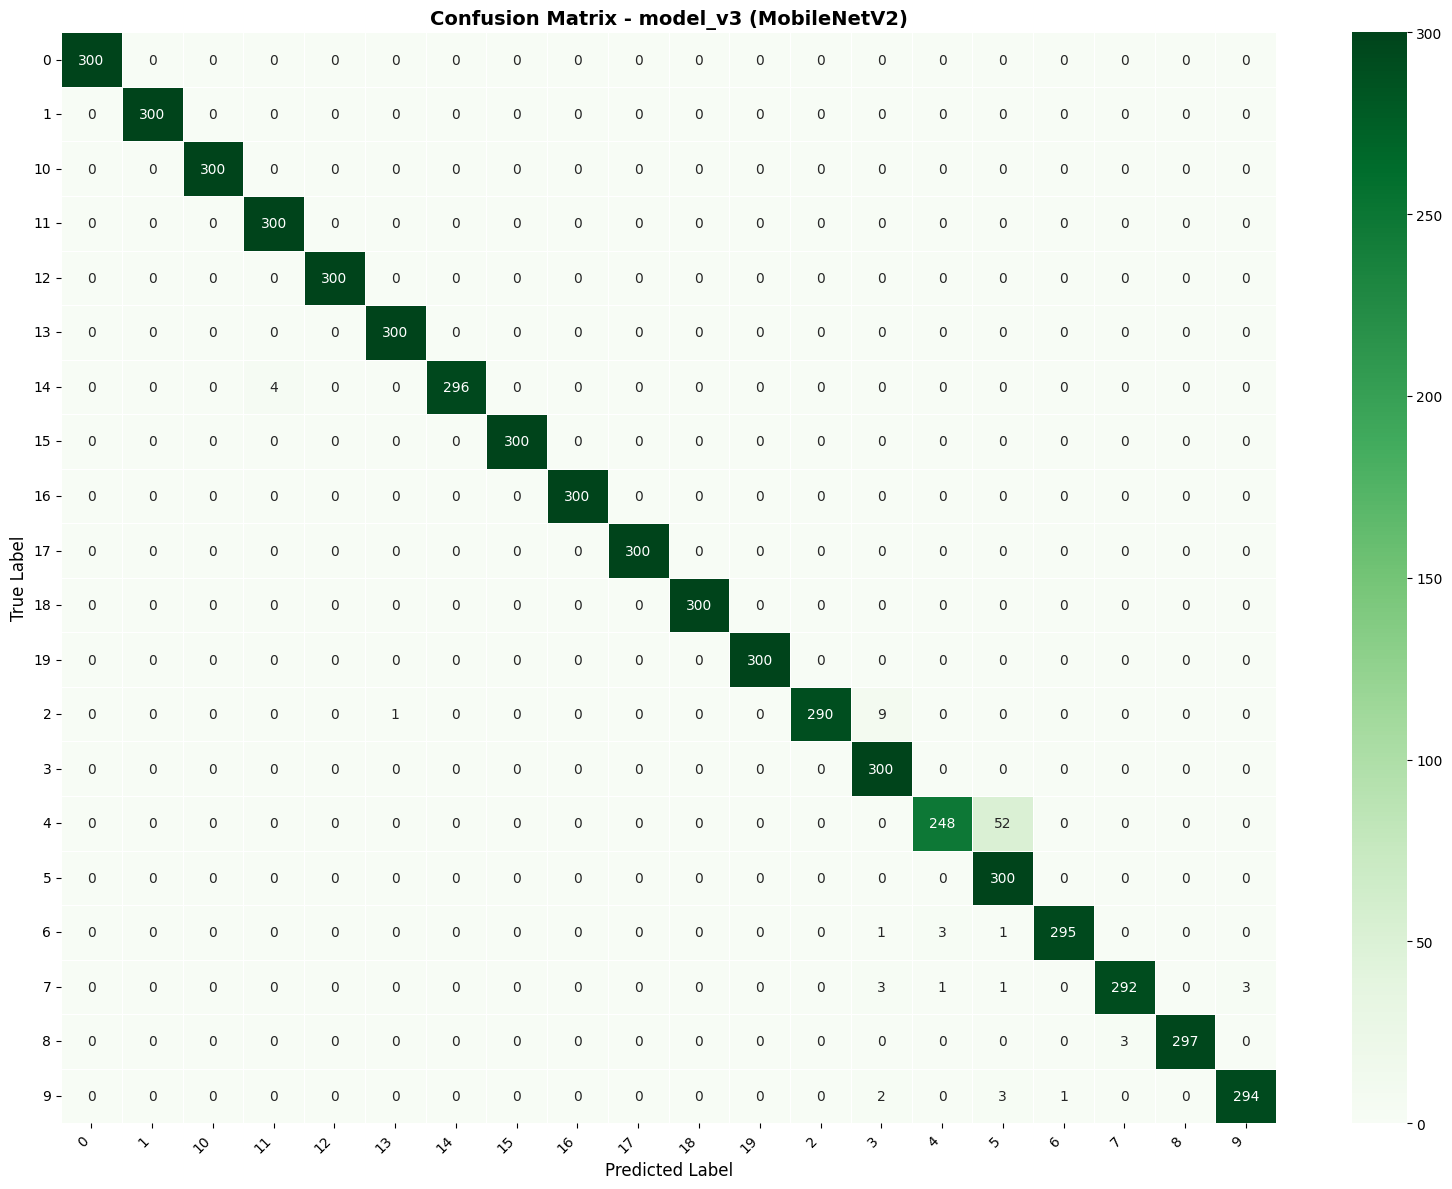

Saved: confusion_matrix_v3.png


In [34]:
cm_v3 = confusion_matrix(y_true_mob, y_pred_v3)

plt.figure(figsize=(16, 12))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - model_v3 (MobileNetV2)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_v3.png")

Metric                               v1       v2       v3
Test Accuracy                    99.98%  100.00%   98.53%
Test Loss                        0.0004   0.0000   0.0471
Dropout                              No      Yes      Yes
BatchNormalization                   No      Yes       No
Data Augmentation                    No      Yes      Yes
EarlyStopping                        No      Yes      Yes
Transfer Learning                    No       No      Yes
Pre-trained Weights                  No       No ImageNet


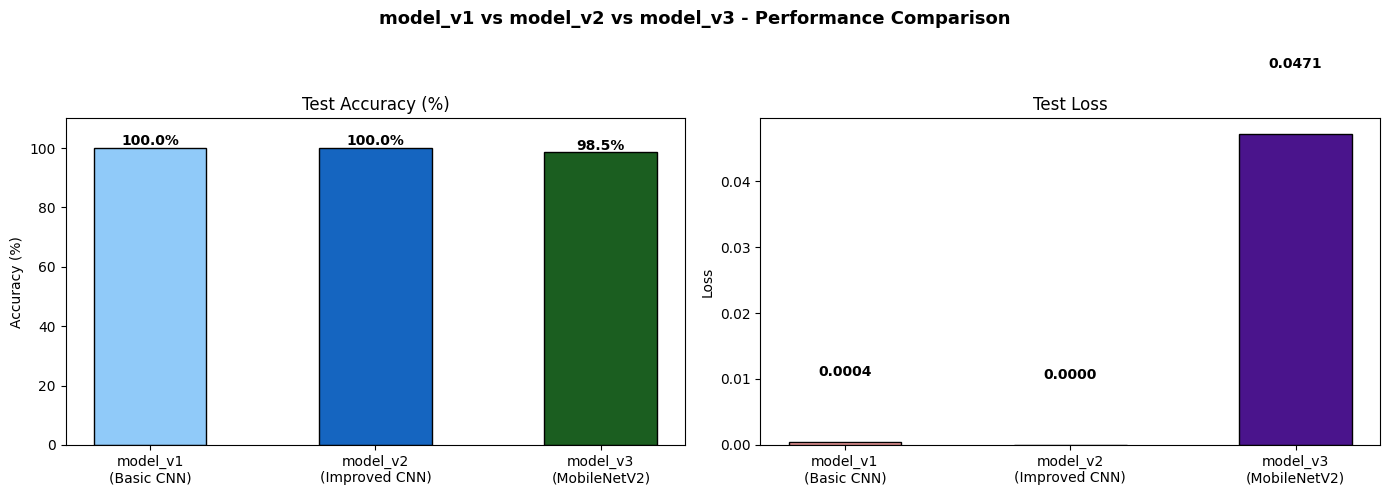

Saved: model_comparison_all.png


In [35]:

V1_TEST_ACC       = 0.9998
V1_TEST_LOSS      = 0.0004

V2_TEST_ACC       = acc_v2
V2_TEST_LOSS      = loss_v2
V3_TEST_ACC       = acc_v3
V3_TEST_LOSS      = loss_v3

print("=" * 60)
print(f"{'Metric':<30} {'v1':>8} {'v2':>8} {'v3':>8}")
print("=" * 60)
print(f"{'Test Accuracy':<30} {V1_TEST_ACC*100:>7.2f}% {V2_TEST_ACC*100:>7.2f}% {V3_TEST_ACC*100:>7.2f}%")
print(f"{'Test Loss':<30} {V1_TEST_LOSS:>8.4f} {V2_TEST_LOSS:>8.4f} {V3_TEST_LOSS:>8.4f}")
print(f"{'Dropout':<30} {'No':>8} {'Yes':>8} {'Yes':>8}")
print(f"{'BatchNormalization':<30} {'No':>8} {'Yes':>8} {'No':>8}")
print(f"{'Data Augmentation':<30} {'No':>8} {'Yes':>8} {'Yes':>8}")
print(f"{'EarlyStopping':<30} {'No':>8} {'Yes':>8} {'Yes':>8}")
print(f"{'Transfer Learning':<30} {'No':>8} {'No':>8} {'Yes':>8}")
print(f"{'Pre-trained Weights':<30} {'No':>8} {'No':>8} {'ImageNet':>8}")
print("=" * 60)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('model_v1 vs model_v2 vs model_v3 - Performance Comparison',
             fontsize=13, fontweight='bold')

models_list = ['model_v1\n(Basic CNN)', 'model_v2\n(Improved CNN)', 'model_v3\n(MobileNetV2)']
accs  = [V1_TEST_ACC*100, V2_TEST_ACC*100, V3_TEST_ACC*100]
losses = [V1_TEST_LOSS, V2_TEST_LOSS, V3_TEST_LOSS]
colors = ['#90CAF9', '#1565C0', '#1B5E20']

axes[0].bar(models_list, accs, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Test Accuracy (%)'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 110])
for i, v in enumerate(accs):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(models_list, losses, color=['#EF9A9A', '#B71C1C', '#4A148C'], edgecolor='black', width=0.5)
axes[1].set_title('Test Loss'); axes[1].set_ylabel('Loss')
for i, v in enumerate(losses):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_all.png")

Best model: model_v2 (Improved CNN) with 100.00% accuracy


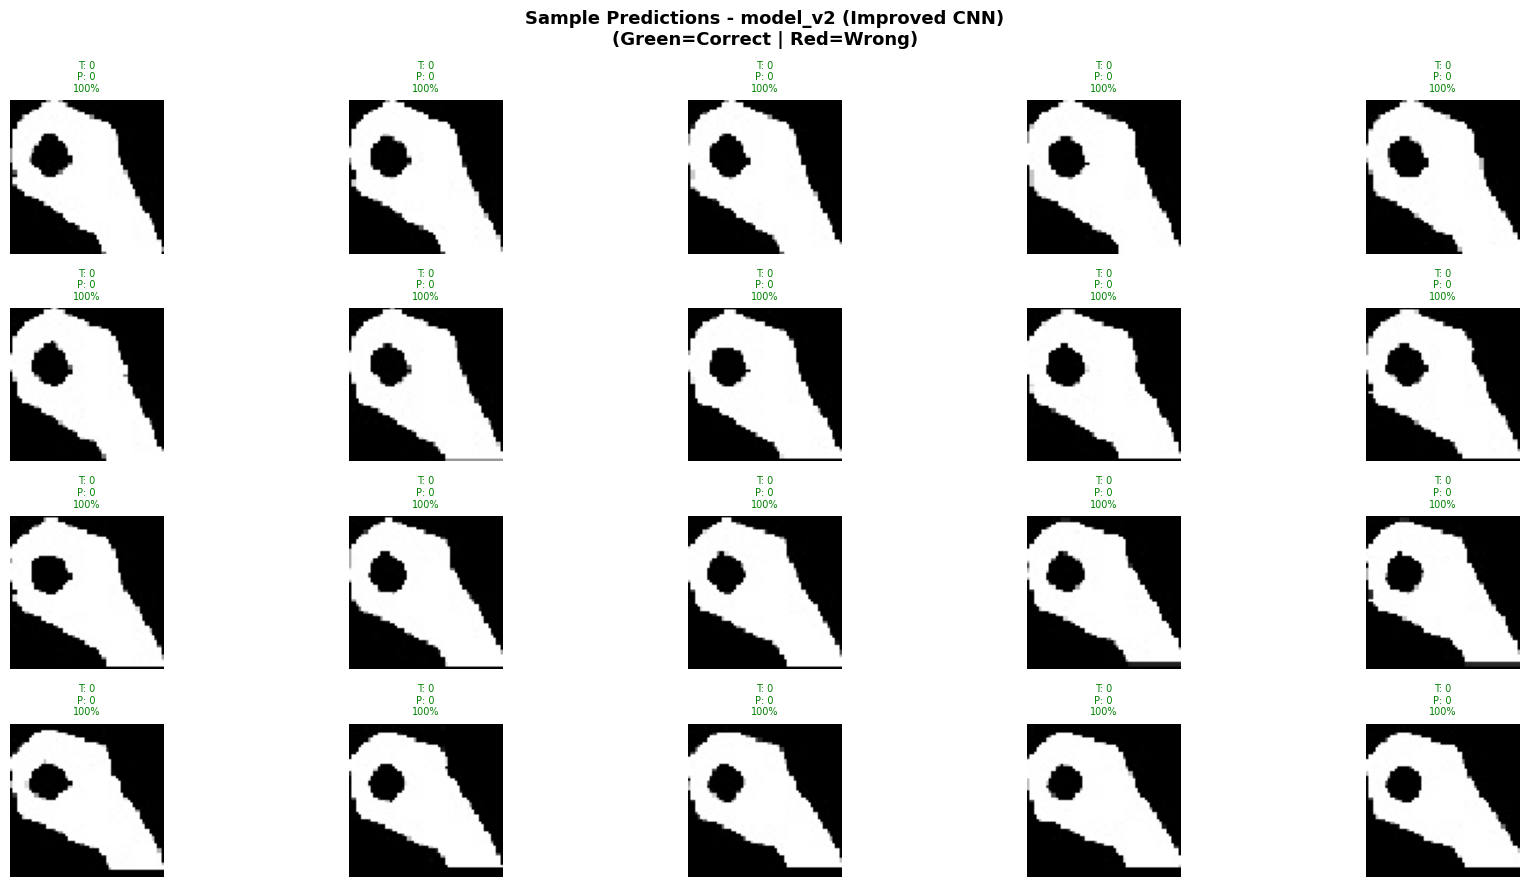

Saved: best_model_predictions.png


In [36]:

best_acc = max(V2_TEST_ACC, V3_TEST_ACC)
if V3_TEST_ACC >= V2_TEST_ACC:
    best_model     = model_v3
    best_gen       = test_gen_mob
    best_model_name = "model_v3 (MobileNetV2)"
else:
    best_model     = model_v2
    best_gen       = test_gen
    best_model_name = "model_v2 (Improved CNN)"

print(f"Best model: {best_model_name} with {best_acc*100:.2f}% accuracy")

best_gen.reset()
sample_imgs, sample_lbls = next(best_gen)
preds = best_model.predict(sample_imgs, verbose=0)

plt.figure(figsize=(18, 9))
plt.suptitle(f'Sample Predictions - {best_model_name}\n(Green=Correct | Red=Wrong)',
             fontsize=13, fontweight='bold')

for i in range(20):
    plt.subplot(4, 5, i + 1)
    img_show = sample_imgs[i]

    if best_model_name != "model_v2 (Improved CNN)":
        img_show = (img_show + 1) / 2.0
    plt.imshow(np.clip(img_show, 0, 1))
    true_lbl = class_names[np.argmax(sample_lbls[i])]
    pred_lbl = class_names[np.argmax(preds[i])]
    conf     = np.max(preds[i]) * 100
    color    = 'green' if true_lbl == pred_lbl else 'red'
    plt.title(f"T: {true_lbl}\nP: {pred_lbl}\n{conf:.0f}%", fontsize=7, color=color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/best_model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: best_model_predictions.png")

In [38]:
model_v2.save('/content/drive/MyDrive/model_v2.keras')
model_v3.save('/content/drive/MyDrive/model_v3.keras')

print("Models saved!")
for fname in ['model_v2.keras', 'model_v3.keras']:
    path = f'/content/drive/MyDrive/{fname}'
    size = os.path.getsize(path) / (1024*1024)
    print(f"  {fname}: {size:.1f} MB")

print("\nAll output files:")
files = [
    'model_v2.keras', 'model_v3.keras',
    'training_curves_v2.png', 'training_curves_v3.png',
    'confusion_matrix_v2.png', 'confusion_matrix_v3.png',
    'augmentation_comparison.png', 'model_comparison_all.png',
    'best_model_predictions.png'
]
for f in files:
    path = f'/content/drive/MyDrive/{f}'
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f"  [{status}] {f}")

Models saved!
  model_v2.keras: 27.5 MB
  model_v3.keras: 22.2 MB

All output files:
  [OK] model_v2.keras
  [OK] model_v3.keras
  [OK] training_curves_v2.png
  [OK] training_curves_v3.png
  [OK] confusion_matrix_v2.png
  [OK] confusion_matrix_v3.png
  [OK] augmentation_comparison.png
  [OK] model_comparison_all.png
  [OK] best_model_predictions.png


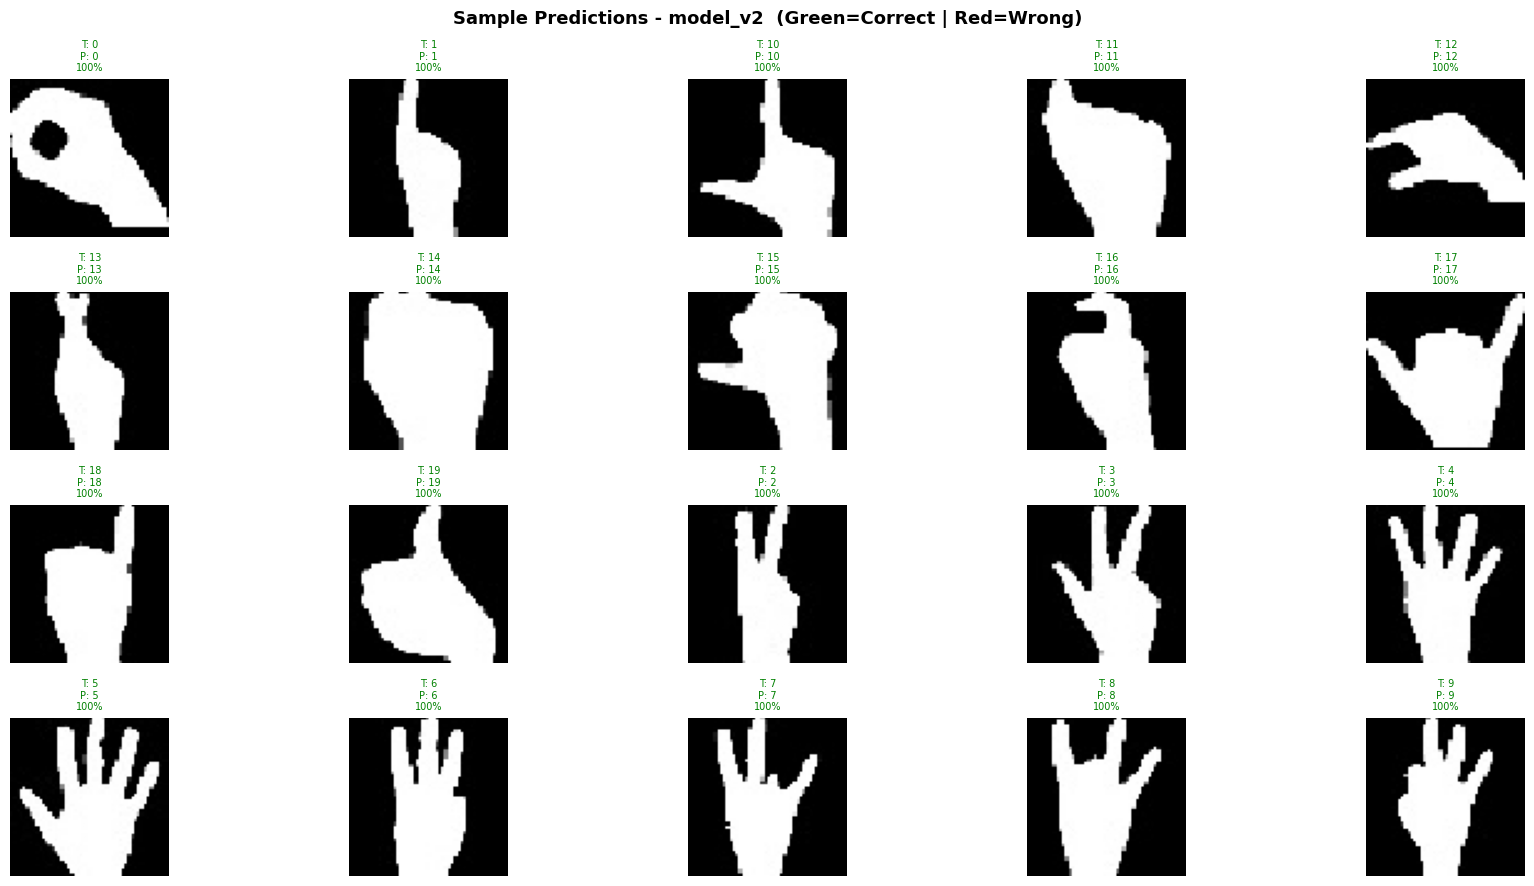

Saved!


In [41]:
import random


random_imgs = []
random_lbls = []


for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)
    images   = os.listdir(cls_path)


    random_img = random.choice(images)
    img_path   = os.path.join(cls_path, random_img)


    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    random_imgs.append(img_array)
    random_lbls.append(cls)

random_imgs = np.array(random_imgs)
preds = model_v2.predict(random_imgs, verbose=0)


plt.figure(figsize=(18, 9))
plt.suptitle('Sample Predictions - model_v2  (Green=Correct | Red=Wrong)',
             fontsize=13, fontweight='bold')

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(random_imgs[i])
    true_lbl = random_lbls[i]
    pred_lbl = class_names[np.argmax(preds[i])]
    conf     = np.max(preds[i]) * 100
    color    = 'green' if true_lbl == pred_lbl else 'red'
    plt.title(f"T: {true_lbl}\nP: {pred_lbl}\n{conf:.0f}%", fontsize=7, color=color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/predictions_v2_varied.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")